# Operating envelope

What lateral acceleration the vehicle can physically reach, and on which surfaces
that is enough to saturate the tires. This decides the radii and speeds used in
steps 5.7 and 5.8: if the platform cannot reach the friction limit, the tire
saturation parameters are not observable and no amount of fitting recovers them.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

L = 0.173          # wheelbase [m]
T = 0.1745         # track [m]
R_WHEEL = 0.03415  # [m], stock tires
G = 9.81

DELTA_MAX = np.deg2rad(30.0)   # nominal, validated in step 5.5
V_MAX = 1.37                   # measured on the ground, loaded (step 5.1)
H_COG = 0.055                  # estimate, measured in step 5.3

/home/pietro/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Max speed

Measured by ramping the `/cmd_vel` setpoint well past the achievable speed and
watching the wheels plateau. `VEHICLE_MAX_LINEAR_VEL_MPS` only clamps the serial
telemetry path, so the PID saw the full setpoint and saturated.

| setpoint [m/s] | plateau [rad/s] |
|---|---|
| 1.7 | 39.1 / 40.1 |
| 2.2 | same |
| 2.6 | same |

Both wheels sit at their own free speed and differ by 2.6%, which is what
saturation looks like: with the loop in control they would track the same
setpoint. Raised the vehicle reaches 41.1 rad/s, so load costs 3.5% of free
speed, i.e. the motors deliver ~3.6% of stall torque at top speed. The limit is
free speed (voltage and gearing), not torque, and there is no torque reserve
left at v_max.

## Kinematic turn radius

At low slip the bicycle model gives

$$R = \frac{L}{\tan \delta}$$

so full lock sets the tightest circle the vehicle can draw.

In [2]:
R_min = L / np.tan(DELTA_MAX)
print(f"R_min = {R_min:.3f} m")

R_min = 0.300 m


## Envelope

On a circle of radius $R$ at speed $v$ the lateral acceleration is $a_y = v^2/R$.
With $v \le v_{max}$ and $R \ge R_{min}$:

$$a_y^{max}(R) = \frac{v_{max}^2}{R}, \qquad R \ge R_{min}$$

The tire saturates where this exceeds the friction limit $\mu g$.

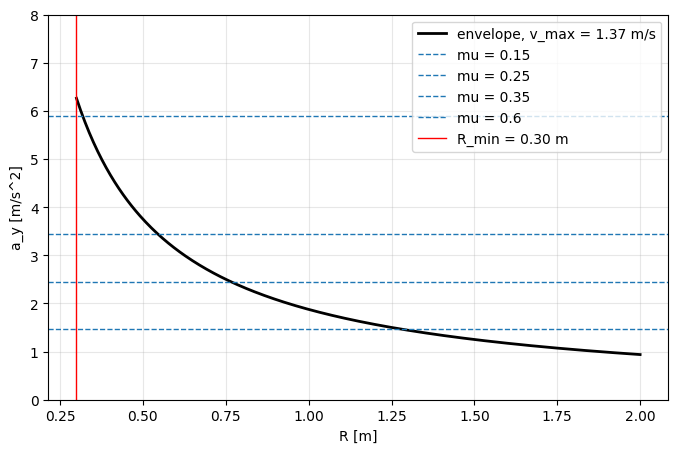

In [3]:
R = np.linspace(R_min, 2.0, 400)
ay_env = V_MAX**2 / R

mus = [0.15, 0.25, 0.35, 0.60]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(R, ay_env, 'k', lw=2, label=f'envelope, v_max = {V_MAX} m/s')
for mu in mus:
    ax.axhline(mu * G, ls='--', lw=1, label=f'mu = {mu}')
ax.axvline(R_min, color='r', lw=1, label=f'R_min = {R_min:.2f} m')
ax.set_xlabel('R [m]')
ax.set_ylabel('a_y [m/s^2]')
ax.set_ylim(0, 8)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [4]:
mu_max = V_MAX**2 / (R_min * G)
print(f"mu_max reachable (kinematic) = {mu_max:.2f}")

mu_max reachable (kinematic) = 0.64


## Operating point

For a given $\mu$, a steady circle at the limit needs $v = \sqrt{\mu g R}$. Larger
radii need more speed, but the locked rear axle scrubs less: the outer wheel would
travel

$$\frac{R + T/2}{R - T/2} - 1$$

more than the inner one, and cannot. Both wheels burn part of their friction
budget longitudinally, leaving less for cornering, and the amount depends on $R$.
Scrub is the column that decides: the largest radius with speed margin wins, and
that needs the lowest $\mu$.

In [5]:
rows = []
for mu in mus:
    for Rc in [0.35, 0.5, 0.7, 0.9, 1.2]:
        if Rc < R_min:
            continue
        v_need = np.sqrt(mu * G * Rc)
        rows.append({
            'mu': mu,
            'R [m]': Rc,
            'v needed [m/s]': round(v_need, 2),
            'v / v_max': round(v_need / V_MAX, 2),
            'spool scrub': round((Rc + T/2) / (Rc - T/2) - 1, 2),
            'space [m]': round(2 * Rc + 0.6, 1),
        })

df = pd.DataFrame(rows)
df['feasible'] = df['v / v_max'] < 0.95
df

,mu,R [m],v needed [m/s],v / v_max,spool scrub,space [m],feasible
0,0.15,0.35,0.72,0.52,0.66,1.3,True
1,0.15,0.50,0.86,0.63,0.42,1.6,True
2,0.15,0.70,1.01,0.74,0.28,2.0,True
3,0.15,0.90,1.15,0.84,0.21,2.4,True
4,0.15,1.20,1.33,0.97,0.16,3.0,False
5,0.25,0.35,0.93,0.68,0.66,1.3,True
6,0.25,0.50,1.11,0.81,0.42,1.6,True
7,0.25,0.70,1.31,0.96,0.28,2.0,False
8,0.25,0.90,1.49,1.08,0.21,2.4,False
9,0.25,1.20,1.72,1.25,0.16,3.0,False


## Rollover check

The vehicle tips instead of sliding above

$$a_y = \frac{T/2}{h_{cog}} g$$

which for a chassis this low sits far beyond the friction limit.

In [6]:
ay_rollover = (T / 2) / H_COG * G
print(f"rollover threshold = {ay_rollover:.1f} m/s^2 = {ay_rollover/G:.2f} g")
print(f"envelope max       = {V_MAX**2/R_min:.1f} m/s^2 = {V_MAX**2/(R_min*G):.2f} g")

rollover threshold = 15.6 m/s^2 = 1.59 g
envelope max       = 6.3 m/s^2 = 0.64 g


## Circle test, stock tires on tiles

Constant radius, five speeds. `/cmd_vel` was scaled to hold $\omega/v$ constant,
so the firmware commanded the same $\delta$ throughout. Yaw rate from the gyro.

Note on the IMU: `imu_link` is rotated -90 deg about Z, so
$a_y^{veh} = -a_x^{imu}$ and the raw `linear_acceleration.y` is longitudinal.
The gyro is unaffected: a rotation about Z leaves the Z axis alone. Lateral
acceleration here is reconstructed as $a_y = v \cdot r$ instead.

In [7]:
v_cmd = np.array([0.4, 0.6, 0.8, 1.0, 1.2])
w_cmd = np.array([1.14, 1.71, 2.29, 2.86, 3.43])
r_meas = np.array([0.83, 1.22, 1.61, 2.02, 2.32])   # gyro mean at steady state

delta = np.arctan(w_cmd * L / v_cmd)
R_cmd = L / np.tan(delta)
R_act = v_cmd / r_meas
ay_act = v_cmd * r_meas

t = pd.DataFrame({
    'v cmd': v_cmd,
    'w cmd': w_cmd,
    'r meas': r_meas,
    'r / w': np.round(r_meas / w_cmd, 3),
    'R act [m]': np.round(R_act, 3),
    'ay [m/s^2]': np.round(ay_act, 2),
})
print(f"delta = {np.rad2deg(delta[0]):.1f} deg, R_cmd = {R_cmd[0]:.2f} m")
t

delta = 26.2 deg, R_cmd = 0.35 m


,v cmd,w cmd,r meas,r / w,R act [m],ay [m/s^2]
0,0.4,1.14,0.83,0.728,0.482,0.33
1,0.6,1.71,1.22,0.713,0.492,0.73
2,0.8,2.29,1.61,0.703,0.497,1.29
3,1.0,2.86,2.02,0.706,0.495,2.02
4,1.2,3.43,2.32,0.676,0.517,2.78


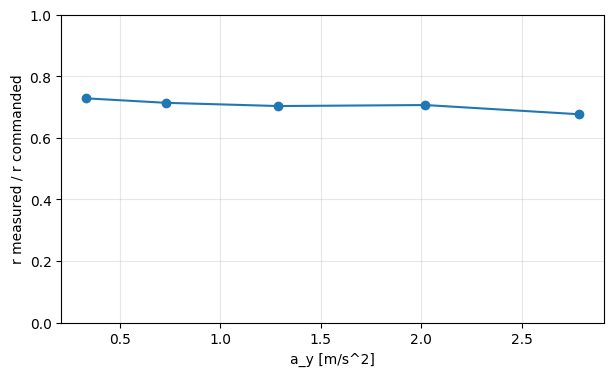

ay reached = 2.78 m/s^2 = 0.28 g
R inflation = 1.42x


In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ay_act, r_meas / w_cmd, 'o-')
ax.set_xlabel('a_y [m/s^2]')
ax.set_ylabel('r measured / r commanded')
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
plt.show()

print(f"ay reached = {ay_act.max():.2f} m/s^2 = {ay_act.max()/G:.2f} g")
print(f"R inflation = {np.mean(R_act/R_cmd):.2f}x")

The ratio holds flat near 0.71 across a 3x range of speed. A saturating tire
would drop it: the car would run wide and yaw rate would fall behind. It does
not, so **stock tires on tiles never reach the limit**, and $\mu > 0.64$.

The constant 29% shortfall is not friction. It is a fixed error, present at every
speed, from the steering ratio, spool scrub (66% at this radius) and wheel slip.
Step 5.5 separates the steering ratio from the rest.

### The envelope is optimistic

The measured radius is 37% larger than the kinematic one, and $a_y = v^2/R$ has
$R$ in the denominator. Redoing the ceiling with the real radius:

In [9]:
infl = np.mean(R_act / R_cmd)
R_min_real = R_min * infl
mu_max_real = V_MAX**2 / (R_min_real * G)
print(f"R_min real  = {R_min_real:.2f} m")
print(f"mu_max real = {mu_max_real:.2f}")

R_min real  = 0.43 m
mu_max real = 0.45


And inflation grows towards the limit, so the true ceiling is lower still.
Target for the slicks: **mu <= 0.2**.

## Slick tires

Rolling radius 29.9 mm and the steering map come from `kinematic_model.ipynb`.
The wheels still plateau at ~40 rad/s, so top speed drops with the radius. Full
lock is +27.4 / -21.8 deg, not 30, and the right side sets a wider circle.

In [10]:
R_SLICK = 0.0299
V_MAX_SLICK = 40.0 * R_SLICK
LOCK = {'left': 27.43, 'right': 21.82}   # deg, measured

print(f"v_max slick = {V_MAX_SLICK:.2f} m/s")
for side, lock in LOCK.items():
    R_lock = L / np.tan(np.radians(lock))
    print(f"{side:5s}: R_min {R_lock:.3f} m, mu ceiling {V_MAX_SLICK**2 / (R_lock * G):.2f}")

v_max slick = 1.20 m/s
left : R_min 0.333 m, mu ceiling 0.44
right: R_min 0.432 m, mu ceiling 0.34


### Circle test, slicks on tiles

Yaw rate read from `ros2 topic echo`, no bag. At 0.35 rad and 0.4 / 0.7 / 1.0 m/s
r/v stays flat: no saturation. At 0.5 rad (26.6 deg real) with the motors at free
speed, r = 3.03 +- 0.43 rad/s over 136 samples, oscillating, tail stepping out.
Saturated, and oversteering.

In [11]:
r_sat = 3.03
R_geom = L / np.tan(np.radians(26.6))

mu_high = V_MAX_SLICK * r_sat / G      # v from the wheels
mu_low = r_sat**2 * R_geom / G         # R from the geometry
print(f"mu from v*r   = {mu_high:.2f}")
print(f"mu from r^2*R = {mu_low:.2f}")

mu from v*r   = 0.37
mu from r^2*R = 0.32


Two bounds. v*r takes v from the wheels, and in a tight circle the spool makes
the wheels turn faster than the car moves, so 0.37 is high. r^2*R takes the
geometric radius, which a sliding car runs wider than, so 0.32 is low. **mu slick
~0.35**, a proper number needs the IMU in a bag (step 5.7).

That is right at the ceiling: the limit is reachable only at full lock, full
speed, **turning left**. Turning right the ceiling (0.34) sits at or below mu.

## Surfaces

| surface | tires | mu | method | saturable |
|---|---|---|---|---|
| tiles | stock | > 0.4 | circle test, r/w flat at 0.71 up to 0.28 g | no |
| tiles | slick | 0.32 - 0.37 | full lock, motors at free speed, r = 3.03 rad/s, tail out | turning left only |

## Test plan

Slicks on tiles for 5.7. Constant radius at full lock turning left (R ~0.33 m,
2R + 0.6 = 1.3 m of floor), speed ramped to v_max, IMU recorded so a_y comes from
the accelerometer mean and not from wheel speed. Enough to see the knee of the
handling diagram, no margin past it. A surface near mu = 0.2 moves the limit to
R ~0.7 m at 1.2 m/s with a third of the scrub, and is what 5.8 needs.